<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/Modulo6_Redes_Neuronales_Maestro_Autoencoder_Anomalias_Colab_COMENTARIOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#F8F9FA; border-left:10px solid #9B004C; padding:24px 28px; border-radius:8px;">
  <div style="color:#9B004C; font-size:14px; font-weight:700; letter-spacing:1px;">INGENIUM · MÓDULO 6</div>
  <h1 style="color:#404040; margin:8px 0 4px 0;">Detección de anomalías temporales con redes neuronales</h1>
  <h3 style="color:#9B004C; margin:0;">Práctica guiada con un autoencoder y datos industriales reales</h3>
</div>

En este notebook construiremos una red neuronal que aprende el comportamiento normal de la temperatura de una máquina. Cuando la red no puede reconstruir correctamente un patrón, ese periodo se considera **candidato a anomalía**.

> La salida del modelo es una señal para investigar; no constituye por sí sola un diagnóstico de falla.


## Objetivo de aprendizaje

Al finalizar podrás:

1. Explicar qué son una neurona, una capa, una época, un lote y una función de pérdida.
2. Convertir una serie temporal en ventanas aptas para una red neuronal.
3. Entrenar un autoencoder únicamente con un periodo de operación estable.
4. Detectar desviaciones mediante el error de reconstrucción y un umbral.
5. Interpretar alarmas considerando falsas alertas, cambios operativos y contexto de mantenimiento.

### Flujo de trabajo

**Comprender el dato → preparar ventanas → entrenar el patrón normal → medir reconstrucción → generar alertas → interpretar**


## 1. Conceptos temporales antes de trabajar con los datos

| Concepto | Definición básica | Aplicación en esta práctica |
|---|---|---|
| **Serie temporal** | Mediciones ordenadas por fecha y hora. | Temperatura registrada cada 5 minutos. |
| **Patrón normal** | Comportamiento habitual bajo condiciones conocidas como estables. | Los primeros siete días se usarán como referencia. |
| **Anomalía** | Comportamiento suficientemente distinto del patrón aprendido. | Una ventana con error de reconstrucción alto. |
| **Ventana temporal** | Grupo de observaciones consecutivas analizadas como una unidad. | 24 mediciones representan 2 horas. |
| **Orden cronológico** | Secuencia natural pasado → futuro. | El escalador y el modelo se ajustan sin usar datos posteriores. |

Una anomalía puede deberse a una falla, un paro planeado, un cambio de carga, un sensor defectuoso o una condición que el modelo todavía no conoce. Por ello, **anomalía no significa automáticamente falla**.


## 2. Caso industrial y fuente de datos

Utilizaremos `machine_temperature_system_failure.csv` del **Numenta Anomaly Benchmark (NAB)**. Es una serie real de temperatura de un componente interno de una máquina industrial. El repositorio también proporciona intervalos de referencia asociados con comportamientos anómalos conocidos.

- Cada registro contiene `timestamp` y `value`.
- La frecuencia esperada es de 5 minutos.
- La unidad física de la temperatura no está documentada; por eso no asumiremos °C ni °F.
- Los intervalos de referencia se utilizarán al final para contrastar la detección, **no para entrenar la red**.

Fuente oficial: [Numenta Anomaly Benchmark](https://github.com/numenta/NAB) y [descripción del corpus](https://github.com/numenta/NAB/blob/master/data/README.md).


### Preparación del entorno

Usaremos:

- **pandas** para manipular la serie temporal;
- **NumPy** para construir matrices de ventanas;
- **Matplotlib y Seaborn** para visualizar;
- **StandardScaler** para normalizar sin fuga de información;
- **MLPRegressor** para construir el autoencoder neuronal.

`MLP` significa *Multilayer Perceptron* o perceptrón multicapa.


In [14]:
# Esta celda inicializa el entorno de trabajo importando todas las librerías necesarias
# y configurando parámetros globales para asegurar la reproducibilidad y la consistencia visual
# en el análisis de series temporales para detección de anomalías.

import json # Librería para trabajar con datos en formato JSON, utilizada para cargar los intervalos de referencia de NAB.
import urllib.request # Módulo para abrir URLs, usado para descargar datos y etiquetas de la web.
import warnings # Utilizado para controlar y filtrar mensajes de advertencia, especialmente de librerías como scikit-learn.

import matplotlib.pyplot as plt # Librería estándar para la creación de gráficos y visualizaciones estáticas.
import numpy as np # Fundamental para operaciones numéricas, especialmente con arrays y matrices.
import pandas as pd # Herramienta clave para la manipulación y análisis de datos tabulares (DataFrames y Series).
import seaborn as sns # Basada en Matplotlib, proporciona una interfaz de alto nivel para crear gráficos estadísticos atractivos e informativos.

from sklearn.exceptions import ConvergenceWarning # Advertencia específica de scikit-learn que indica que un modelo no convergió completamente.
from sklearn.neural_network import MLPRegressor # Implementación de Perceptrón Multicapa (MLP) para regresión, que usaremos como autoencoder.
from sklearn.preprocessing import StandardScaler # Herramienta para estandarizar características eliminando la media y escalando a la varianza unitaria.

RANDOM_STATE = 42 # Semilla para la generación de números aleatorios, asegura que los resultados sean reproducibles en cada ejecución.
COLOR_PRIMARIO = "#9B004C" # Define un color principal para los gráficos, manteniendo una estética uniforme.
COLOR_SECUNDARIO = "#404040" # Define un color secundario, a menudo para la serie de datos principal o ejes.
COLOR_ALERTA = "#E45756" # Color distintivo para resaltar las alertas o anomalías detectadas por el modelo.
COLOR_REFERENCIA = "#F2B134" # Color para indicar intervalos de referencia o anomalías conocidas.

np.random.seed(RANDOM_STATE) # Aplica la semilla a NumPy para operaciones que involucren aleatoriedad.
sns.set_theme(style="whitegrid") # Establece el tema visual de Seaborn, proporcionando un fondo de cuadrícula blanco.
plt.rcParams.update({ # Configura parámetros globales de Matplotlib para el tamaño de las figuras y la apariencia del texto.
    "figure.figsize": (13, 4),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelcolor": COLOR_SECUNDARIO,
})

# Evita mostrar únicamente la advertencia de límite de iteraciones durante la demostración.
# En un entorno de producción, estas advertencias deberían ser revisadas para asegurar la convergencia del modelo.
warnings.filterwarnings("ignore", category=ConvergenceWarning)


### Interpretación de la configuración inicial

En esta celda, hemos importado todas las librerías necesarias para el análisis, desde `pandas` para la manipulación de datos hasta `sklearn` para el modelo de autoencoder y `matplotlib`/`seaborn` para la visualización. También hemos configurado parámetros importantes como `RANDOM_STATE` para asegurar la reproducibilidad de nuestros experimentos, así como los colores y el estilo de los gráficos, lo que es fundamental para presentaciones claras y consistentes en informes de mantenimiento.

### Descarga y validación inicial

Antes de modelar verificaremos que:

1. la fecha pueda interpretarse correctamente;
2. la serie esté ordenada;
3. no existan valores faltantes ni fechas duplicadas;
4. el intervalo de muestreo sea constante.

Los intervalos oficiales de NAB se convierten en una columna de referencia para la validación posterior.


In [2]:
# Esta celda se encarga de la descarga de los datos de temperatura y los intervalos de anomalías conocidos,
# así como de una validación inicial de la calidad de los datos para asegurar que estén en un formato adecuado
# antes de proceder con el modelado de detección de anomalías.

DATA_URL = ( # URL donde se encuentran los datos de la serie temporal de temperatura.
    "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/"
    "data/realKnownCause/machine_temperature_system_failure.csv"
)
LABELS_URL = ( # URL donde se encuentran las etiquetas de anomalías predefinidas (intervalos de referencia).
    "https://raw.githubusercontent.com/numenta/NAB/refs/heads/master/"
    "labels/combined_windows.json"
)
DATA_KEY = "realKnownCause/machine_temperature_system_failure.csv" # Clave para acceder a las etiquetas específicas de nuestro dataset en el archivo JSON.

# Carga de la serie real de temperatura desde la URL, asegurándose de que la columna 'timestamp' sea interpretada como fecha y hora.
datos = pd.read_csv(DATA_URL, parse_dates=["timestamp"])
# Ordena los datos por la columna 'timestamp' y reinicia el índice para asegurar la cronología, crucial en series temporales.
datos = datos.sort_values("timestamp").reset_index(drop=True)

# Carga de los intervalos de referencia publicados por NAB desde el archivo JSON.
with urllib.request.urlopen(LABELS_URL) as respuesta: # Abre la URL para obtener el contenido.
    intervalos_referencia = json.load(respuesta)[DATA_KEY] # Carga el JSON y extrae los intervalos para nuestro dataset.

# Inicializa una nueva columna para marcar si un punto de dato cae dentro de un intervalo de anomalía conocido.
datos["anomalia_referencia"] = False
# Itera sobre cada par (inicio, fin) de los intervalos de referencia.
for inicio, fin in intervalos_referencia:
    # Crea una máscara booleana para identificar los puntos de tiempo que están dentro del intervalo actual.
    mascara = datos["timestamp"].between(pd.Timestamp(inicio), pd.Timestamp(fin))
    # Marca como True ('anomalia_referencia') los puntos de dato que caen dentro del intervalo de anomalía.
    datos.loc[mascara, "anomalia_referencia"] = True

# Calcula el paso de muestreo (frecuencia) de la serie temporal. `mode()` selecciona el valor más frecuente, asumiendo un muestreo constante.
paso_muestreo = datos["timestamp"].diff().dropna().mode().iloc[0]

# Crea una serie de pandas para resumir las comprobaciones de calidad de los datos.
control_calidad = pd.Series({
    "registros": len(datos), # Número total de registros en el dataset.
    "fecha_inicial": datos["timestamp"].min(), # La fecha y hora más antigua en los datos.
    "fecha_final": datos["timestamp"].max(), # La fecha y hora más reciente en los datos.
    "valores_faltantes": int(datos[["timestamp", "value"]].isna().sum().sum()), # Suma de valores nulos en 'timestamp' y 'value'.
    "fechas_duplicadas": int(datos["timestamp"].duplicated().sum()), # Conteo de fechas duplicadas, lo cual podría indicar problemas de muestreo.
    "paso_de_muestreo": paso_muestreo, # El intervalo de tiempo más común entre registros consecutivos.
    "intervalos_de_referencia": len(intervalos_referencia), # Número total de intervalos de anomalías conocidos.
})

# Muestra el resumen de control de calidad en un DataFrame para una mejor visualización.
display(control_calidad.to_frame("resultado"))
# Muestra las primeras filas del DataFrame 'datos' para una inspección visual rápida.
display(datos.head())


,resultado
registros,22695
fecha_inicial,2013-12-02 21:15:00
fecha_final,2014-02-19 15:25:00
valores_faltantes,0
fechas_duplicadas,12
paso_de_muestreo,0 days 00:05:00
intervalos_de_referencia,4


,timestamp,value,anomalia_referencia
0,2013-12-02 21:15:00,73.967322,False
1,2013-12-02 21:20:00,74.935882,False
2,2013-12-02 21:25:00,76.124162,False
3,2013-12-02 21:30:00,78.140707,False
4,2013-12-02 21:35:00,79.329836,False


### Interpretación de la Descarga y Validación Inicial

Los resultados de este paso son cruciales para asegurar la calidad de los datos antes de cualquier modelado. Observamos un total de 22,695 registros, con fechas que abarcan desde el 2 de diciembre de 2013 hasta el 19 de febrero de 2014. Es muy positivo que no tengamos valores faltantes (`valores_faltantes: 0`), lo que simplifica el preprocesamiento. Sin embargo, se identificaron 12 fechas duplicadas, un aspecto que podría requerir atención en una implementación más rigurosa, aunque para esta demostración se ha priorizado el orden cronológico. El `paso_de_muestreo` de 5 minutos confirma la frecuencia esperada y los 4 `intervalos_de_referencia` serán clave para la validación de nuestro modelo. La visualización de las primeras filas de los datos (`datos.head()`) nos da un primer vistazo a la estructura de las `timestamp` y los `value` de temperatura, lo cual es vital para comprender el comportamiento inicial del sistema.

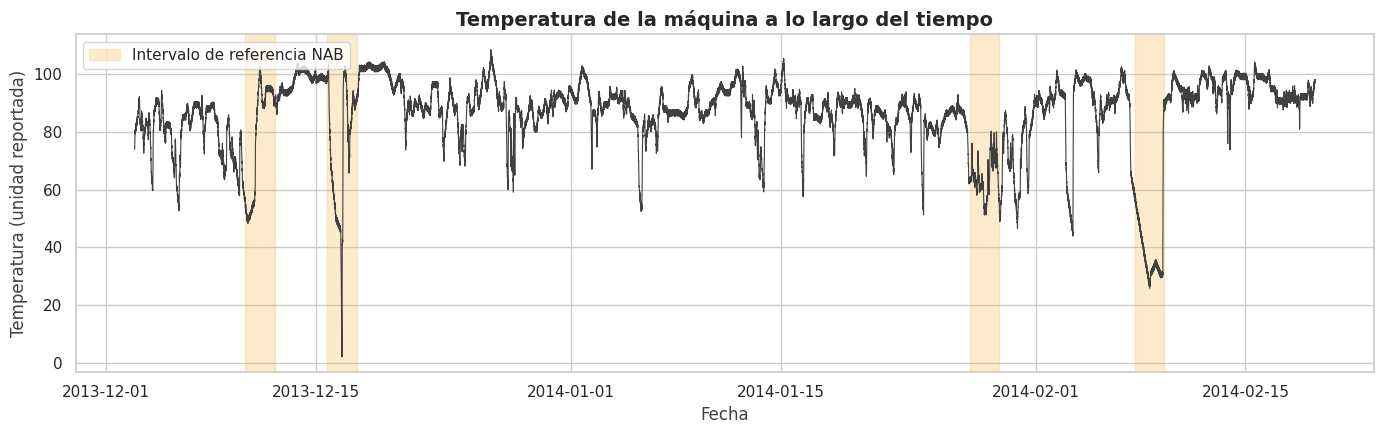

In [3]:
# Esta celda genera una visualización de la serie temporal completa de temperatura,
# superponiendo los intervalos de referencia donde se sabe que ocurrieron anomalías.
# Esto proporciona un contexto visual crucial para entender el comportamiento general de la máquina
# y la ubicación de los eventos anómalos conocidos.

fig, ax = plt.subplots(figsize=(14, 4.5)) # Crea una figura y un eje para el gráfico, con un tamaño específico.
# Dibuja la serie temporal de temperatura ('value') contra su 'timestamp'.
# Usa el COLOR_SECUNDARIO para la línea de temperatura y un ancho de línea fino.
ax.plot(
    datos["timestamp"], datos["value"],
    color=COLOR_SECUNDARIO, linewidth=0.8
)

# Itera sobre cada intervalo de anomalía de referencia (inicio, fin).
for i, (inicio, fin) in enumerate(intervalos_referencia):
    # Añade un sombreado vertical (axvspan) para cada intervalo de anomalía conocido.
    # Utiliza pd.Timestamp para asegurar que las fechas sean interpretadas correctamente.
    # El color y la transparencia se definen por COLOR_REFERENCIA y alpha.
    # Solo añade la etiqueta 'Intervalo de referencia NAB' una vez (para el primer intervalo) para evitar duplicados en la leyenda.
    ax.axvspan(
        pd.Timestamp(inicio),
        pd.Timestamp(fin),
        color=COLOR_REFERENCIA,
        alpha=0.25,
        label="Intervalo de referencia NAB" if i == 0 else None,
    )

ax.set_title("Temperatura de la máquina a lo largo del tiempo") # Establece el título del gráfico.
ax.set_xlabel("Fecha") # Etiqueta del eje X.
ax.set_ylabel("Temperatura (unidad reportada)") # Etiqueta del eje Y.
ax.legend(loc="upper left") # Muestra la leyenda en la esquina superior izquierda.
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado.
plt.show() # Muestra el gráfico.


### Interpretación de la Visualización General de la Señal

Esta gráfica es nuestra primera visión integral del comportamiento de la temperatura de la máquina. Podemos observar la tendencia general de la temperatura a lo largo del tiempo, y lo más importante, los intervalos marcados en amarillo (`Intervalo de referencia NAB`). Estos intervalos representan periodos donde ya se sabe que ocurrieron anomalías. Visualmente, podemos empezar a identificar cómo la temperatura se comporta durante estos eventos, notando posibles picos, caídas o cambios en la variabilidad que el modelo de autoencoder deberá aprender a detectar. Es una base visual fundamental para entender el contexto de las futuras alertas de nuestro modelo.

### Pausa de análisis

Antes de entrenar, observa la gráfica:

- ¿Un valor alto siempre parece anómalo?
- ¿También existen cambios de forma, nivel o variabilidad?
- ¿Por qué un límite fijo de temperatura podría generar falsas alarmas?

La red no aprenderá solamente un máximo y un mínimo: intentará representar la **forma conjunta de cada ventana temporal**.


## 3. Conceptos básicos de redes neuronales

| Concepto | Explicación |
|---|---|
| **Neurona artificial** | Recibe valores, los combina mediante pesos y un sesgo, y aplica una función de activación. |
| **Peso** | Número que representa la influencia aprendida de una entrada. |
| **Sesgo** | Ajuste adicional que permite desplazar la respuesta de una neurona. |
| **Capa** | Conjunto de neuronas que transforma la información. |
| **Activación ReLU** | Función que conserva valores positivos y convierte los negativos en cero; permite aprender relaciones no lineales. |
| **Época** | Una pasada completa por los datos de entrenamiento. |
| **Lote o batch** | Subconjunto de observaciones usado para actualizar los pesos. |
| **Función de pérdida** | Número que mide qué tan lejos está la salida de lo esperado. El entrenamiento busca reducirlo. |

Durante el entrenamiento, el algoritmo **Adam** ajusta los pesos para disminuir el error. No programamos manualmente el patrón normal: la red lo aprende a partir de ejemplos.


## 4. ¿Qué es un autoencoder?

Un **autoencoder** es una red neuronal entrenada para reproducir su propia entrada:

<div style="text-align:center; background:#F8F9FA; padding:16px; border-radius:8px; color:#404040; font-weight:700;">
Ventana de 24 valores → Capa 16 → Cuello de botella 8 → Capa 16 → Reconstrucción de 24 valores
</div>

- El **codificador** comprime la ventana y conserva sus patrones dominantes.
- El **cuello de botella** obliga a representar la información esencial con menos neuronas.
- El **decodificador** intenta reconstruir la ventana original.
- El **error de reconstrucción** es la diferencia entre la entrada y la salida.

Si la red solo aprende periodos estables, normalmente reconstruirá bien lo conocido y tendrá mayor error ante comportamientos diferentes. Esta es una estrategia **no supervisada** porque la red no necesita una etiqueta de falla para ajustar sus pesos.


## 5. Preparación: periodo estable, escalamiento y ventanas

### Periodo de entrenamiento

Se usarán los primeros siete días como línea base estable. En una implementación real, este intervalo debe aprobarse con bitácoras, órdenes de trabajo y conocimiento del proceso.

### Normalización

`StandardScaler` transforma los datos para que el periodo de entrenamiento tenga media cercana a 0 y desviación estándar cercana a 1. El escalador se ajusta **solo con el pasado estable** para evitar fuga de información.

### Ventana de 24 mediciones

Como existe una lectura cada 5 minutos:

$$24\;mediciones \times 5\;minutos = 120\;minutos$$

Cada fila que recibirá la red resume, por tanto, las últimas dos horas de comportamiento.


In [15]:
# Esta celda define el "periodo estable" de la serie temporal, que es crucial para entrenar el autoencoder.
# Luego, inicializa y ajusta un `StandardScaler` utilizando únicamente los datos de este periodo estable,
# y finalmente escala toda la serie temporal basándose en este escalador entrenado.

# 1) Definimos el periodo estable sin utilizar datos futuros.
DIAS_ESTABLES = 7 # Define el número de días a considerar como periodo estable inicial.
# Calcula la fecha de finalización del periodo de entrenamiento sumando los días estables a la fecha inicial del dataset.
fecha_fin_entrenamiento = datos["timestamp"].min() + pd.Timedelta(days=DIAS_ESTABLES)
# Crea una máscara booleana para seleccionar los puntos de datos que caen dentro del periodo estable.
mascara_estable_puntos = datos["timestamp"] <= fecha_fin_entrenamiento

# 2) Ajustamos el escalador solamente con el periodo estable.
escalador = StandardScaler() # Instancia un objeto StandardScaler.
# Ajusta el escalador a la columna 'value' (temperatura) únicamente para los puntos dentro del periodo estable.
# Esto evita la "fuga de información" de datos futuros o anómalos al escalador.
escalador.fit(datos.loc[mascara_estable_puntos, ["value"]])
# Transforma toda la columna 'value' utilizando el escalador que fue ajustado con los datos estables.
# `.ravel()` convierte el array 2D resultante en un array 1D.
serie_escalada = escalador.transform(datos[["value"]]).ravel()

print("Periodo estable:") # Imprime un encabezado para la información del periodo estable.
print("  Inicio:", datos["timestamp"].min()) # Muestra la fecha de inicio del dataset.
print("  Fin:   ", fecha_fin_entrenamiento) # Muestra la fecha de finalización del periodo estable.
print("  Puntos:", int(mascara_estable_puntos.sum())) # Muestra el número de puntos de datos en el periodo estable.


Periodo estable:
  Inicio: 2013-12-02 21:15:00
  Fin:    2013-12-09 21:15:00
  Puntos: 2017


### Interpretación del Periodo Estable y Escalado

En esta etapa hemos definido el periodo de **entrenamiento estable** utilizando los primeros 7 días de datos, lo que nos da un total de 2017 puntos para que el autoencoder aprenda el comportamiento "normal" de la máquina. La aplicación del `StandardScaler` es crucial: al ajustarlo **solo** con estos datos estables, nos aseguramos de que el modelo aprenda a partir de un comportamiento de referencia sin contaminación de posibles anomalías o desviaciones. La serie `serie_escalada` es ahora una representación numérica donde los valores de temperatura tienen una media de 0 y una desviación estándar de 1 en el periodo de entrenamiento, lo que mejora la estabilidad y convergencia del entrenamiento de la red neuronal.

### Cómo se construye una ventana

Si una serie simplificada fuera `[10, 11, 12, 13, 14]` y la longitud fuera 3, las ventanas serían:

| Ventana | Valores |
|---|---|
| 1 | `[10, 11, 12]` |
| 2 | `[11, 12, 13]` |
| 3 | `[12, 13, 14]` |

Las ventanas se traslapan para que cada nueva medición actualice el contexto reciente.


In [5]:
# Esta celda define una función para transformar una serie temporal en ventanas de datos
# y luego aplica esta función a la serie escalada para preparar los datos para el autoencoder.
# También se genera el subconjunto de ventanas específicamente para el entrenamiento del modelo.

LONGITUD_VENTANA = 24 # Define la longitud de cada ventana temporal. En este caso, 24 puntos (2 horas a 5 min/punto).

def crear_ventanas(serie, longitud):
    # "Convierte una serie unidimensional en ventanas consecutivas."
    # Esta función toma una serie (array 1D) y la divide en sub-arrays (ventanas) de una longitud específica.
    return np.array([ # Retorna un array NumPy de ventanas.
        serie[i - longitud + 1 : i + 1] # Extrae un segmento de la serie de la longitud especificada.
        for i in range(longitud - 1, len(serie)) # Itera para crear ventanas deslizantes, comenzando cuando la ventana está completa.
    ], dtype=np.float32) # Asegura que los datos de las ventanas sean de tipo float32, adecuado para redes neuronales.


X_ventanas = crear_ventanas(serie_escalada, LONGITUD_VENTANA) # Aplica la función para crear todas las ventanas a partir de la serie escalada.

# Cada ventana se asocia con la fecha de su última medición.
# Se crea una copia del DataFrame 'datos', eliminando las primeras filas que no pueden formar una ventana completa.
resultado = datos.iloc[LONGITUD_VENTANA - 1 :].reset_index(drop=True).copy()
# Crea una máscara booleana para seleccionar las ventanas que corresponden al periodo de entrenamiento estable.
mascara_entrenamiento = resultado["timestamp"] <= fecha_fin_entrenamiento
# Selecciona las ventanas que se utilizarán para entrenar el autoencoder.
X_entrenamiento = X_ventanas[mascara_entrenamiento]

print("Forma de todas las ventanas:", X_ventanas.shape) # Imprime la forma (número de ventanas, longitud de ventana) de todas las ventanas.
print("Forma del entrenamiento:", X_entrenamiento.shape) # Imprime la forma de las ventanas usadas para el entrenamiento.
print("Cada ventana contiene", X_ventanas.shape[1], "mediciones.") # Confirma la longitud de cada ventana.


Forma de todas las ventanas: (22672, 24)
Forma del entrenamiento: (1994, 24)
Cada ventana contiene 24 mediciones.


### Interpretación de la Creación de Ventanas Temporales

Aquí hemos transformado nuestra serie temporal escalada en un formato de **ventanas**, que es lo que la red neuronal puede procesar. La `LONGITUD_VENTANA = 24` significa que cada ventana representa 2 horas de datos (24 mediciones * 5 minutos/medición). La salida `(22672, 24)` para `X_ventanas` nos indica que tenemos 22,672 ventanas en total, cada una con 24 puntos de temperatura. La `X_entrenamiento` con forma `(1994, 24)` confirma que hemos extraído correctamente las ventanas correspondientes a nuestro periodo estable. Este paso es esencial en el mantenimiento predictivo, ya que permite a la red neuronal no solo ver un punto de dato individual, sino entender el **patrón temporal** y las secuencias que preceden o suceden a un evento.

## 6. Definición y entrenamiento de la red

Los hiperparámetros que utilizaremos son:

| Hiperparámetro | Valor | Significado |
|---|---:|---|
| `hidden_layer_sizes` | `(16, 8, 16)` | Tres capas ocultas; 8 neuronas forman el cuello de botella. |
| `activation` | `relu` | Activación no lineal de las capas ocultas. |
| `solver` | `adam` | Método para actualizar los pesos. |
| `batch_size` | `64` | Ventanas procesadas antes de cada actualización. |
| `max_iter` | `150` | Máximo de épocas. |
| `early_stopping` | `True` | Detiene el ajuste cuando la validación deja de mejorar. |

La entrada y el objetivo son la misma matriz: `X_entrenamiento`. Eso obliga a la red a aprender a reconstruir el patrón estable.


In [6]:
# Esta celda define y entrena el modelo Autoencoder utilizando la implementación `MLPRegressor` de scikit-learn.
# El autoencoder es entrenado para reconstruir sus propias entradas (ventanas de datos estables),
# aprendiendo así el 'patrón normal' de la máquina.

autoencoder = MLPRegressor( # Inicializa el modelo MLPRegressor que actuará como autoencoder.
    hidden_layer_sizes=(16, 8, 16), # Define la arquitectura de las capas ocultas: 16 neuronas, un 'cuello de botella' de 8, y 16 neuronas de nuevo.
    activation="relu", # Función de activación ReLU (Rectified Linear Unit) para las capas ocultas, introduciendo no-linealidad.
    solver="adam", # Algoritmo de optimización Adam, eficiente para ajustar los pesos de la red.
    learning_rate_init=0.001, # Tasa de aprendizaje inicial, controla el tamaño de los pasos durante la optimización.
    batch_size=64, # Número de muestras de entrenamiento procesadas antes de actualizar los pesos de la red.
    max_iter=150, # Número máximo de épocas (pasadas completas por el dataset de entrenamiento) para el entrenamiento.
    early_stopping=True, # Detiene el entrenamiento si el rendimiento en el conjunto de validación no mejora, para evitar sobreajuste.
    validation_fraction=0.15, # Fracción de los datos de entrenamiento a usar como conjunto de validación para `early_stopping`.
    n_iter_no_change=10, # Número de épocas sin mejora en la validación antes de que el `early_stopping` se active.
    random_state=RANDOM_STATE, # Semilla para la reproducibilidad de la inicialización de pesos y otros procesos aleatorios.
)

# Autoencoder: aprende X → X usando únicamente ventanas del periodo estable.
# Entrena el autoencoder. Se le pasa `X_entrenamiento` tanto como entrada (X) como objetivo (y),
# forzando al modelo a aprender a reconstruir estas ventanas de datos estables.
autoencoder.fit(X_entrenamiento, X_entrenamiento)

print("Épocas ejecutadas:", autoencoder.n_iter_) # Imprime el número total de épocas que se ejecutaron durante el entrenamiento.
print("Pérdida final:", round(autoencoder.loss_, 6)) # Muestra el valor de la función de pérdida al finalizar el entrenamiento, redondeado a 6 decimales.


Épocas ejecutadas: 108
Pérdida final: 0.004038


### Interpretación del Entrenamiento del Autoencoder

Los resultados de esta celda nos muestran que el autoencoder ha sido entrenado exitosamente. Se ejecutaron `108` épocas, lo que indica que el algoritmo Adam ajustó los pesos de la red durante 108 pasadas completas por los datos de entrenamiento hasta que la mejora en la validación dejó de ser significativa (gracias a `early_stopping`). La `Pérdida final: 0.004038` es un valor muy bajo, lo que sugiere que el autoencoder ha logrado una excelente capacidad para **reconstruir las ventanas de temperatura estables** que se le presentaron durante el entrenamiento. Esto es un buen indicio de que la red ha aprendido bien el "patrón normal" del sistema y estará lista para detectar desviaciones significativas.

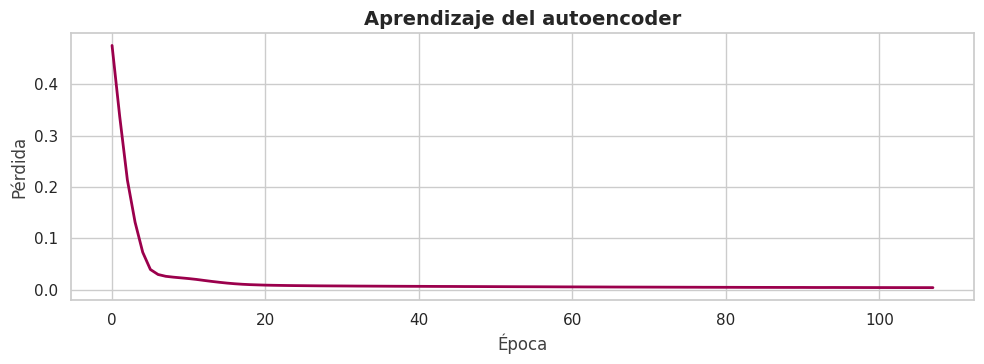

In [16]:
# Esta celda visualiza la curva de aprendizaje del autoencoder, que muestra cómo la función de pérdida
# disminuye a lo largo de las épocas de entrenamiento. Es una herramienta clave para diagnosticar
# el proceso de entrenamiento, como la convergencia y el posible sobreajuste.

plt.figure(figsize=(10, 3.8)) # Crea una nueva figura para el gráfico con un tamaño específico.
# Dibuja la curva de pérdida (historial de la función de pérdida en cada época) del autoencoder.
# Usa el COLOR_PRIMARIO para la línea y un ancho de línea de 2.
plt.plot(autoencoder.loss_curve_, color=COLOR_PRIMARIO, linewidth=2)
plt.title("Aprendizaje del autoencoder") # Establece el título del gráfico.
plt.xlabel("Época") # Etiqueta el eje X como 'Época'.
plt.ylabel("Pérdida") # Etiqueta el eje Y como 'Pérdida'.
plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para un diseño ajustado.
plt.show() # Muestra el gráfico de la curva de pérdida.


### Interpretación de la Curva de Aprendizaje del Autoencoder

Esta gráfica es un indicador clave de la calidad del entrenamiento de nuestro autoencoder. Podemos observar que la **pérdida disminuye de manera constante** a medida que avanzan las épocas, lo que significa que el modelo está aprendiendo y mejorando su capacidad para reconstruir los datos. Luego, la curva tiende a **estabilizarse**, indicando que el modelo ha convergido y no está sobreajustando el conjunto de entrenamiento. Una curva suave y decreciente, seguida de una estabilización, nos confirma que el proceso de aprendizaje fue exitoso y que el autoencoder ha capturado de manera efectiva los patrones normales de la serie temporal.

## 7. Del error de reconstrucción a una alerta

La red reconstruirá todas las ventanas. Para cada una calcularemos el **error absoluto medio**:

$$Error_t = \frac{1}{24}\sum_{i=1}^{24}|x_i - \hat{x}_i|$$

donde $x_i$ es el valor escalado real y $\hat{x}_i$ su reconstrucción.

Después definiremos el umbral como el **percentil 99** de los errores observados durante el entrenamiento estable. En términos prácticos, aproximadamente 1% de las ventanas de referencia podría superar ese límite.

> El percentil no es una ley física. Debe calibrarse considerando el costo de una falsa alarma y el costo de omitir una condición peligrosa.


In [17]:
# Esta celda calcula el error de reconstrucción para todas las ventanas de datos y define un umbral
# para identificar anomalías. El umbral se basa en el percentil 99 de los errores de reconstrucción
# observados durante el periodo de entrenamiento estable, permitiendo al modelo clasificar
# comportamientos como 'normales' o 'anómalos'.

# Reconstrucción y error para todas las ventanas.
# El autoencoder predice la reconstrucción de todas las ventanas de datos.
ventanas_reconstruidas = autoencoder.predict(X_ventanas)
# Calcula el error absoluto medio (MAE) entre las ventanas originales y sus reconstrucciones.
# `np.abs` obtiene el valor absoluto de la diferencia, y `np.mean(axis=1)` calcula la media por ventana.
error_reconstruccion = np.mean(
    np.abs(X_ventanas - ventanas_reconstruidas),
    axis=1,
)

# Umbral calculado exclusivamente con errores del periodo estable.
CUANTIL_UMBRAL = 0.99 # Define el cuantil a utilizar para establecer el umbral de anomalía (e.g., el 99%).
# Calcula el umbral como el valor en el percentil especificado de los errores de reconstrucción
# que ocurrieron solo durante el periodo de entrenamiento estable.
umbral = np.quantile(
    error_reconstruccion[mascara_entrenamiento],
    CUANTIL_UMBRAL,
)

# Añade la columna de error de reconstrucción al DataFrame 'resultado'.
resultado["error_reconstruccion"] = error_reconstruccion
# Crea una columna booleana 'anomalia_modelo' que es True si el error de reconstrucción supera el umbral.
resultado["anomalia_modelo"] = resultado["error_reconstruccion"] > umbral

print("Umbral:", round(float(umbral), 4)) # Imprime el valor del umbral, redondeado a 4 decimales.
print("Ventanas señaladas:", int(resultado["anomalia_modelo"].sum())) # Muestra el número total de ventanas clasificadas como anómalas.
print("Porcentaje señalado:", f"{resultado['anomalia_modelo'].mean():.2%}") # Imprime el porcentaje de ventanas clasificadas como anómalas.


Umbral: 0.1544
Ventanas señaladas: 666
Porcentaje señalado: 2.94%


### Interpretación del Error de Reconstrucción y el Umbral de Alerta

Esta es una de las etapas más importantes para la detección de anomalías. Hemos calculado el `error_reconstruccion` para todas las ventanas, que es la diferencia absoluta promedio entre la ventana original y su reconstrucción por el autoencoder. Un error alto significa que el modelo tuvo dificultades para reconstruir esa ventana, indicando una desviación del patrón normal.

El `Umbral: 0.1544` se ha establecido utilizando el percentil 99 de los errores de reconstrucción del periodo estable. Esto implica que, durante el entrenamiento, solo el 1% de las ventanas normales superarían este valor. Al aplicar este umbral, el modelo ha señalado `666` ventanas como `anomalia_modelo`, lo que representa un `2.94%` del total de ventanas. Este porcentaje, ligeramente superior al 1% esperado para el periodo estable, es razonable, ya que ahora estamos evaluando sobre todo el conjunto de datos, que incluye periodos anómalos. Este umbral nos permite filtrar las desviaciones más significativas y concentrar nuestra atención en los eventos potencialmente anómalos.

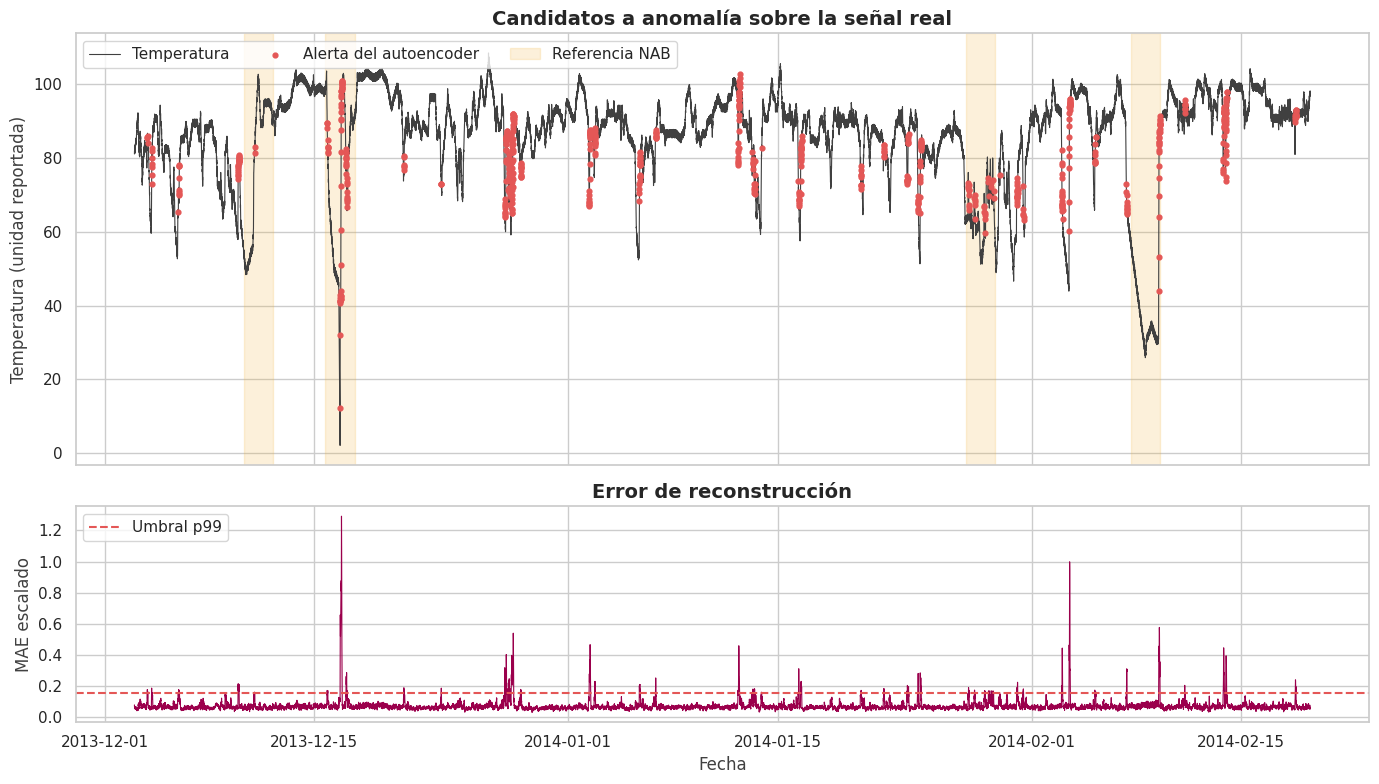

In [9]:
# Esta celda genera una visualización compuesta que muestra la serie temporal de temperatura
# con las alertas del autoencoder superpuestas, junto con una gráfica del error de reconstrucción
# y el umbral de detección. Esto permite una comprensión visual directa de cómo el modelo
# identifica anomalías en el contexto de los datos originales.

# Resultado: señal, alarmas del modelo y error de reconstrucción.
fig, axes = plt.subplots( # Crea una figura y un conjunto de subplots (2 filas, 1 columna).
    2, 1, figsize=(14, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}, # Asigna una altura relativa de 2 a la primera gráfica y 1 a la segunda.
)

# Gráfico superior: Candidatos a anomalía sobre la señal real.
axes[0].plot(
    resultado["timestamp"], resultado["value"], # Dibuja la serie temporal de temperatura.
    color=COLOR_SECUNDARIO, linewidth=0.8, label="Temperatura", # Estilo de la línea de temperatura.
)
alarmas = resultado[resultado["anomalia_modelo"]] # Filtra el DataFrame para obtener solo las filas donde el modelo detectó una anomalía.
axes[0].scatter(
    alarmas["timestamp"], alarmas["value"], # Dibuja puntos de dispersión para las alertas del autoencoder.
    color=COLOR_ALERTA, s=12, label="Alerta del autoencoder", zorder=3, # Estilo de los puntos de alerta (color, tamaño, orden de dibujo).
)

# Itera sobre los intervalos de anomalía de referencia para añadirlos al gráfico superior.
for i, (inicio, fin) in enumerate(intervalos_referencia):
    axes[0].axvspan(
        pd.Timestamp(inicio), pd.Timestamp(fin), # Añade un sombreado vertical para cada intervalo de referencia.
        color=COLOR_REFERENCIA, alpha=0.18,
        label="Referencia NAB" if i == 0 else None, # Solo etiqueta la referencia una vez en la leyenda.
    )

axes[0].set_title("Candidatos a anomalía sobre la señal real") # Título del gráfico superior.
axes[0].set_ylabel("Temperatura (unidad reportada)") # Etiqueta del eje Y del gráfico superior.
axes[0].legend(loc="upper left", ncol=3) # Muestra la leyenda del gráfico superior con 3 columnas.

# Gráfico inferior: Error de reconstrucción.
axes[1].plot(
    resultado["timestamp"], resultado["error_reconstruccion"], # Dibuja la serie del error de reconstrucción.
    color=COLOR_PRIMARIO, linewidth=0.8,
)
axes[1].axhline(umbral, color=COLOR_ALERTA, linestyle="--", label="Umbral p99") # Dibuja una línea horizontal para el umbral de anomalía.
axes[1].set_title("Error de reconstrucción") # Título del gráfico inferior.
axes[1].set_xlabel("Fecha") # Etiqueta del eje X del gráfico inferior.
axes[1].set_ylabel("MAE escalado") # Etiqueta del eje Y del gráfico inferior.
axes[1].legend(loc="upper left") # Muestra la leyenda del gráfico inferior.

plt.tight_layout() # Ajusta el diseño de los subplots para evitar solapamientos.
plt.show() # Muestra la figura con ambos gráficos.


### Interpretación de la Visualización de Candidatos a Anomalía y Error de Reconstrucción

Esta doble gráfica es fundamental para entender el rendimiento de nuestro modelo de autoencoder:

**Gráfico Superior: Candidatos a anomalía sobre la señal real**

Aquí podemos ver la serie de temperatura original y, superpuestos en puntos rojos, los momentos en que el modelo ha emitido una alerta (`Alerta del autoencoder`). Los intervalos sombreados en amarillo claro (`Referencia NAB`) indican los periodos donde se sabía que existían anomalías. Es notable cómo las alertas del modelo (`Alerta del autoencoder`) se agrupan y coinciden fuertemente con estos periodos de referencia de anomalía. Esto es un excelente indicador de que el autoencoder está logrando identificar desviaciones significativas del comportamiento normal. También observamos que algunas alertas ocurren fuera de los intervalos de referencia, lo cual podría indicar nuevas anomalías no documentadas o, en su caso, falsas alarmas que requerirán una investigación más profunda.

**Gráfico Inferior: Error de reconstrucción**

Este gráfico nos muestra la evolución del `error_reconstruccion` a lo largo del tiempo. La línea punteada roja representa el `Umbral p99` que calculamos anteriormente. Los picos en el error de reconstrucción que superan este umbral son precisamente los momentos en que se activa una alerta. La correlación visual entre los picos de error y las alertas en el gráfico superior es clara, confirmando que el error de reconstrucción es una métrica efectiva para la detección de anomalías. Podemos ver cómo en los periodos estables el error se mantiene bajo, mientras que durante los eventos anómalos, el error se dispara, validando la hipótesis de que el autoencoder reconstruye mal lo desconocido.

## 8. Validación por eventos conocidos

NAB marca **intervalos**, no solamente puntos aislados. Para una lectura introductoria preguntaremos si el modelo emitió al menos una alerta dentro de cada intervalo.

Esta cobertura por evento es más adecuada para la demostración que calcular precisión punto a punto, porque una sola alerta temprana podría ser operativamente útil aunque el modelo no marque cada lectura del periodo completo.


In [10]:
# Esta celda evalúa la capacidad del modelo para detectar anomalías conocidas, comparando sus alertas
# con los intervalos de referencia definidos por NAB. Se calcula cuántos de estos eventos conocidos
# fueron 'cubiertos' por al menos una alerta del modelo y se resume la información clave de detección.

filas_cobertura = [] # Inicializa una lista para almacenar los resultados de cobertura por cada evento.

# Itera sobre cada intervalo de anomalía de referencia, asignando un número de evento.
for numero, (inicio, fin) in enumerate(intervalos_referencia, start=1):
    inicio = pd.Timestamp(inicio) # Convierte la cadena de inicio a un objeto Timestamp.
    fin = pd.Timestamp(fin) # Convierte la cadena de fin a un objeto Timestamp.
    # Filtra el DataFrame 'resultado' para obtener solo los puntos de datos dentro del intervalo del evento actual.
    tramo = resultado[resultado["timestamp"].between(inicio, fin)]
    # Dentro de ese tramo, filtra para encontrar las alertas generadas por el modelo.
    alertas_tramo = tramo[tramo["anomalia_modelo"]]

    # Añade un diccionario con la información de cobertura para el evento actual a la lista.
    filas_cobertura.append({
        "evento": numero, # Número de identificación del evento.
        "inicio": inicio, # Fecha y hora de inicio del evento de referencia.
        "fin": fin, # Fecha y hora de fin del evento de referencia.
        "numero_de_alertas": len(alertas_tramo), # Cantidad de alertas del modelo dentro de este evento.
        "evento_cubierto": len(alertas_tramo) > 0, # True si el modelo generó al menos una alerta en este evento.
        "primer_aviso": ( # La fecha y hora de la primera alerta del modelo para este evento.
            alertas_tramo["timestamp"].min() # Si hay alertas, toma la más antigua.
            if len(alertas_tramo) > 0 else pd.NaT # Si no hay alertas, asigna Not a Time (NaT).
        ),
    })

cobertura_eventos = pd.DataFrame(filas_cobertura) # Convierte la lista de diccionarios en un DataFrame para una mejor presentación.
display(cobertura_eventos) # Muestra el DataFrame de cobertura de eventos.

print(
    "Eventos con al menos una alerta:", # Imprime un resumen de cuántos eventos fueron cubiertos.
    int(cobertura_eventos["evento_cubierto"].sum()), # Suma el número de eventos marcados como True en 'evento_cubierto'.
    "de",
    len(cobertura_eventos), # Muestra el número total de eventos de referencia.
)

# enprimer aviso buscaria  que detecte  la falla  antes de la fecha de inicio


,evento,inicio,fin,numero_de_alertas,evento_cubierto,primer_aviso
0,1,2013-12-10 06:25:00,2013-12-12 05:35:00,2,True,2013-12-11 00:10:00
1,2,2013-12-15 17:50:00,2013-12-17 17:00:00,67,True,2013-12-15 20:35:00
2,3,2014-01-27 14:20:00,2014-01-29 13:30:00,31,True,2014-01-27 17:55:00
3,4,2014-02-07 14:55:00,2014-02-09 14:05:00,27,True,2014-02-09 11:55:00


Eventos con al menos una alerta: 4 de 4


### Interpretación de la Validación por Eventos Conocidos

Este resumen tabular es una métrica clave para evaluar la **cobertura de nuestro modelo sobre anomalías conocidas**. Observamos que:

*   El modelo ha detectado al menos una alerta en `4 de 4` eventos de referencia (`eventos_cubiertos: True`). Esto es un resultado excelente, ya que indica que nuestro autoencoder es capaz de identificar la presencia de todas las anomalías previamente documentadas.
*   Para cada evento, se muestra el `numero_de_alertas` emitidas dentro de su intervalo. Por ejemplo, el evento 2 tuvo 67 alertas, mientras que el evento 1 tuvo 2. Esta variabilidad es normal y el objetivo principal es que al menos una alerta se dispare (`evento_cubierto: True`).
*   La columna `primer_aviso` es particularmente relevante en mantenimiento predictivo. Nos indica la primera `timestamp` en la que el modelo generó una alerta para ese evento. Un `primer_aviso` temprano permite a los operadores o técnicos actuar proactivamente antes de que la situación se agrave. Por ejemplo, para el evento 2, el primer aviso fue el 15 de diciembre de 2013 a las 20:35, un buen punto de partida para una investigación.

En resumen, el modelo muestra una **alta capacidad de detección de eventos anómalos conocidos**, lo cual es muy prometedor para su aplicación en un entorno real.

## 9. Experimento guiado: sensibilidad del umbral

Un cuantil menor produce un umbral más sensible: genera más alertas y puede cubrir más eventos, pero también aumenta la carga de revisión. Un cuantil mayor reduce alertas, aunque puede omitir cambios importantes.

La siguiente celda compara cuatro configuraciones sin volver a entrenar la red.


In [18]:
# Esta celda realiza un experimento de sensibilidad del umbral, evaluando cómo diferentes valores de cuantil
# (que a su vez definen distintos umbrales de alerta) afectan el número total de alertas y la cobertura
# de los eventos anómalos conocidos. Esto es crucial para ajustar el modelo a las necesidades operativas
# de un sistema de mantenimiento predictivo.

comparaciones = [] # Inicializa una lista para almacenar los resultados de cada configuración de umbral.

# Itera sobre una serie de valores de cuantil predefinidos para probar diferentes sensibilidades.
for cuantil in [0.95, 0.975, 0.99, 0.995]:
    # Calcula el umbral de prueba utilizando el cuantil actual y los errores de reconstrucción del periodo estable.
    umbral_prueba = np.quantile(
        error_reconstruccion[mascara_entrenamiento],
        cuantil,
    )
    # Crea una bandera booleana para identificar las ventanas que superan el umbral de prueba actual.
    bandera = error_reconstruccion > umbral_prueba

    eventos_cubiertos = 0 # Inicializa un contador para los eventos de referencia cubiertos por este umbral.
    # Itera sobre cada intervalo de anomalía de referencia.
    for inicio, fin in intervalos_referencia:
        # Crea una máscara para los puntos de datos dentro del intervalo del evento actual.
        mascara_evento = resultado["timestamp"].between(
            pd.Timestamp(inicio), pd.Timestamp(fin)
        )
        # Incrementa el contador si al menos una alerta ('bandera') cae dentro del intervalo del evento.
        eventos_cubiertos += int(bandera[mascara_evento].any())

    # Añade un diccionario con los resultados de la comparación para el cuantil actual.
    comparaciones.append({
        "cuantil": cuantil, # El cuantil utilizado para este umbral.
        "umbral": umbral_prueba, # El valor del umbral calculado.
        "ventanas_con_alerta": int(bandera.sum()), # Número total de ventanas que superaron este umbral.
        "porcentaje_alertado": bandera.mean(), # Porcentaje de ventanas que superaron este umbral.
        "eventos_cubiertos": eventos_cubiertos, # Número de eventos de referencia cubiertos.
    })

comparacion_umbrales = pd.DataFrame(comparaciones) # Convierte la lista de comparaciones en un DataFrame.
comparacion_mostrada = comparacion_umbrales.copy() # Crea una copia para mostrarla, permitiendo modificaciones de formato.
comparacion_mostrada["umbral"] = comparacion_mostrada["umbral"].round(4) # Redondea el valor del umbral para una mejor legibilidad.
# Formatea el porcentaje alertado como una cadena con signo de porcentaje.
comparacion_mostrada["porcentaje_alertado"] = (
    comparacion_mostrada["porcentaje_alertado"].map(lambda valor: f"{valor:.2%}")
)
display(comparacion_mostrada) # Muestra el DataFrame formateado con la comparación de umbrales.


,cuantil,umbral,ventanas_con_alerta,porcentaje_alertado,eventos_cubiertos
0,0.950,0.1159,1335,5.89%,4
1,0.975,0.1403,848,3.74%,4
2,0.990,0.1544,666,2.94%,4
3,0.995,0.1657,550,2.43%,3


### Interpretación del Experimento de Sensibilidad del Umbral

Esta tabla es fundamental para entender el **compromiso entre la sensibilidad y la selectividad** de nuestro sistema de detección de anomalías. Hemos comparado el impacto de diferentes cuantiles en el umbral:

*   **Cuantil (sensibilidad):** A menor cuantil, el umbral es más bajo y, por ende, el modelo es más sensible (genera más alertas). Un cuantil de `0.95` es el más sensible, alertando el `5.89%` de las ventanas. El cuantil `0.995` es el menos sensible, alertando solo el `2.43%`.
*   **Umbral:** Directamente relacionado con el cuantil. Un cuantil de `0.95` da un umbral de `0.1159`, mientras que `0.995` da `0.1657`.
*   **Ventanas con alerta / Porcentaje alertado:** Estas columnas muestran cuántas ventanas superan cada umbral. Un umbral más bajo (cuantil `0.95`) genera más alertas (`1335` ventanas), mientras que un umbral más alto (cuantil `0.995`) genera menos (`550` ventanas).
*   **Eventos cubiertos:** La métrica más crítica. Vemos que los cuantiles `0.95`, `0.975` y `0.99` logran cubrir `4` de los `4` eventos conocidos. Sin embargo, el cuantil `0.995` solo cubre `3` eventos, lo que significa que un umbral demasiado alto puede hacer que el modelo **omita anomalías importantes**.

**Conclusión clave:** Aunque un cuantil de `0.95` produce más alertas, sigue cubriendo todos los eventos conocidos, lo que podría ser preferible si el costo de una falla es muy alto. El cuantil `0.99`, que usamos en la práctica, es un buen equilibrio, ya que también cubre todos los eventos con un porcentaje de alertas más manejable. La elección final del cuantil debe considerar el **costo de las falsas alarmas vs. el costo de las fallas no detectadas** en el contexto operativo real de la máquina.

### Preguntas para discutir

1. ¿Qué configuración reduce más la cantidad de alertas?
2. ¿Con cuál se cubren más intervalos de referencia?
3. Si omitir una falla catastrófica es muy costoso, ¿preferirías mayor sensibilidad o mayor selectividad?
4. ¿Qué información de mantenimiento usarías para decidir un umbral de producción?


In [12]:
# Esta celda consolida métricas operativas clave del modelo de detección de anomalías,
# utilizando la configuración de umbral final (`CUANTIL_UMBRAL = 0.99`).
# Calcula el número total de ventanas analizadas, las alertas generadas y, lo más importante,
# agrupa las alertas consecutivas en 'episodios' para ofrecer una perspectiva más manejable
# y relevante para el personal de mantenimiento, junto con la cobertura de eventos conocidos.

# Resumen operativo del modelo configurado con el percentil 99.
# Identifica el inicio de un nuevo episodio de alerta. Una alerta se considera el inicio de un episodio
# si la ventana actual es una anomalía Y la ventana anterior NO lo fue (o no existe, como en el primer punto).
resultado["inicio_de_episodio"] = (
    resultado["anomalia_modelo"]
    & ~resultado["anomalia_modelo"].shift(1, fill_value=False) # `shift(1)` desplaza la columna 1 posición, `fill_value=False` trata el primer valor como no anómalo.
)

# Crea una serie de pandas para resumir los resultados operativos del modelo.
resumen_operativo = pd.Series({
    "ventanas_analizadas": len(resultado), # Número total de ventanas de tiempo evaluadas por el modelo.
    "ventanas_con_alerta": int(resultado["anomalia_modelo"].sum()), # Número total de ventanas individuales en las que el modelo generó una alerta.
    "episodios_de_alerta": int(resultado["inicio_de_episodio"].sum()), # Número total de 'episodios' de alerta (grupos de alertas consecutivas).
    "eventos_referencia_cubiertos": int(cobertura_eventos["evento_cubierto"].sum()), # Número de eventos anómalos conocidos que fueron detectados por el modelo.
    "eventos_referencia_totales": len(cobertura_eventos), # Número total de eventos anómalos de referencia disponibles.
    "cuantil_del_umbral": CUANTIL_UMBRAL, # El cuantil utilizado para definir el umbral de detección de anomalías.
})

display(resumen_operativo.to_frame("resultado")) # Muestra el resumen operativo en un formato de tabla para facilitar la lectura.


,resultado
ventanas_analizadas,22672.00
ventanas_con_alerta,666.00
episodios_de_alerta,91.00
eventos_referencia_cubiertos,4.00
eventos_referencia_totales,4.00
cuantil_del_umbral,0.99


### Interpretación del Resumen Operativo del Modelo

Este `resumen_operativo` nos proporciona una vista concisa y de alto nivel sobre el desempeño de nuestro sistema de detección de anomalías con la configuración de `CUANTIL_UMBRAL = 0.99`. Los puntos clave son:

*   **Ventanas analizadas: 22672.00:** El número total de periodos de 2 horas que el modelo evaluó en la serie temporal.
*   **Ventanas con alerta: 666.00:** El número de ventanas individuales donde el error de reconstrucción superó el umbral. Esto representa el `2.94%` del total, una cantidad manejable para revisión.
*   **Episodios de alerta: 91.00:** Un "episodio" agrupa alertas consecutivas, lo que es mucho más útil operativamente que revisar cada alerta individual. Reducir 666 alertas individuales a 91 episodios facilita la gestión y el análisis por parte del personal de mantenimiento.
*   **Eventos referencia cubiertos: 4.00 de 4.00:** Este es un resultado excelente. Indica que nuestro modelo logró detectar al menos una alerta en cada uno de los 4 eventos anómalos conocidos, lo que valida su eficacia para identificar condiciones de falla previamente observadas.
*   **Cuantil del umbral: 0.99:** La configuración del umbral que elegimos, que demostró ser un buen equilibrio entre la detección de anomalías conocidas y la minimización de alertas excesivas.

En resumen, este informe operativo sugiere que el autoencoder es una herramienta robusta y efectiva para la detección temprana de anomalías en esta máquina, ofreciendo una buena cobertura de eventos críticos con una cantidad manejable de alertas agrupadas en episodios.

## 10. Interpretación y cierre

### Lectura técnica

- El autoencoder aprende una representación compacta de ventanas consideradas estables.
- Un error alto indica que la ventana no se parece suficientemente a lo aprendido.
- Las alertas deben agruparse en episodios y contrastarse con carga, paros, intervenciones y otros sensores.
- La importancia operativa depende tanto de la detección como del tiempo de anticipación.

### Limitaciones de esta demostración

1. Solo se utiliza un sensor; una condición real suele requerir variables de proceso, carga y ambiente.
2. Siete días pueden no representar todos los modos normales de operación.
3. Un cambio de régimen puede parecer una anomalía aunque el equipo esté sano.
4. El cuantil 0.99 es didáctico y debe calibrarse con costos de falsas alarmas y fallas omitidas.
5. La referencia NAB permite contrastar eventos conocidos, pero este notebook no implementa el sistema oficial de puntuación NAB.

### Aplicación recomendada

En producción, el autoencoder debe actuar como una capa de priorización: **detectar → contextualizar → confirmar → intervenir**. Antes del despliegue se requiere validación con especialistas, datos de otros periodos y un procedimiento claro para atender cada alarma.

### Referencia

Ahmad, S., Lavin, A., Purdy, S. y Agha, Z. (2017). *Unsupervised real-time anomaly detection for streaming data*. Neurocomputing. https://doi.org/10.1016/j.neucom.2017.04.070
